# 03 · Replicating Giannone, Reichlin & Small (2008) — an approximation

Giannone, Reichlin & Small (2008, *JME*; "GRS") introduced the modern nowcasting
framework: a **two-step dynamic factor model** estimated on a large monthly panel
(about 200 US series), with the factors extracted by principal components, their
dynamics by a VAR, and the ragged edge handled by the Kalman filter (formalised in
Doz, Giannone & Reichlin, 2011). Quarterly GDP growth is then linked to the
quarterly average of the factors by a **bridge equation**. Their two main findings:

1. the nowcast becomes more precise as monthly data for the quarter accumulate;
2. the model beats naive benchmarks and matches the Survey of Professional
   Forecasters, i.e. it extracts the information professionals use.

> **This is an approximation, not an exact replication.** The original GRS data files
> are not available from a primary source, so `nowcastbox` ships
> `load_us_grs_like()`: the FRED-MD database (McCracken & Ng, 2016) restricted to
> 1982–2004 with FRED-MD transformations and stylised publication delays. It differs
> from GRS in four ways: **118 instead of ~200 series** (copyrighted series such as the
> S&P 500, Moody's yields and Michigan sentiment are excluded), **current (revised)
> vintages** instead of the real-time data GRS reconstructed for part of their
> exercise, FRED-MD definitions, and one delay per series. Numbers will therefore not
> match the paper's tables; the *qualitative* findings are what we check.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from utils import display, md, setup, show

import nowcastbox as nb

setup()

## 1. Data

In [2]:
ds = nb.load_us_grs_like()  # 1982-01 .. 2004-12 by default
print(ds.summary())
print("\n" + ds.notes)

Dataset 'us_grs_like': GRS (2008)-like US panel built from FRED-MD
  Sample        : 1982-01 to 2004-12 (276 months)
  Series        : 118 (M: 117, Q: 1)
  Categories    : hard: 87, financial: 31
  Blocks        : global, output_income, consumption_orders, labor, housing, money_credit, rates_fx, prices
  Target        : GDPC1
  License       : FRED-MD/FRED-QD are distributed freely by the Federal Reserve Bank of St. Louis for research. The shipped series come from US government agencies (BEA, BLS, Census, Federal Reserve Board, Treasury; public domain) or are constructed by McCracken & Ng; series under third-party copyright are excluded (see 'excluded_for_license').
  Sources       : FRED-MD vintage 2026-08 (revised): https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed/research/fred-md/monthly/2026-rev-08-md.csv; FRED-QD vintage 2026-08 (revised): https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed/research/fred-md/quarterly/2026-rev-08-qd.csv

The original GRS (2008)

In [3]:
panel = nb.prepare_panel(ds.data, ds.transform)
display(ds.legend.groupby("blocks").size().rename("series per FRED-MD group").to_frame())
md(
    f"After `prepare_panel`: **{panel.n_series - 1} monthly predictors** + real GDP "
    f"(quarterly, log-difference), {panel.start} to {panel.end}."
)

,series per FRED-MD group
blocks,
global;consumption_orders,9
global;housing,10
global;labor,31
global;money_credit,13
global;output_income,17
global;prices,20
global;rates_fx,18


After `prepare_panel`: **116 monthly predictors** + real GDP (quarterly, log-difference), 1982-01 to 2004-12.

## 2. The two-step model

We use the specification commonly employed to replicate GRS (for example in the
documentation of the R package `nowcasting`, de Valk et al., 2019): **r = 2** static
factors, a **VAR(2)** for the factors and **q = 2** dynamic shocks, with the factors
aggregated to quarterly frequency before the bridge regression (`aggregate="factors"`,
the "2s_agg" variant). The Bai & Ng (2002) criteria would choose more factors on this
panel (notebook 04); with a quarterly bridge regression on ~90 observations,
parsimony pays.

In [4]:
model = nb.TwoStepDFM(n_factors=2, factor_lags=2, n_shocks=2, aggregate="factors")
res = model.fit(panel, target="GDPC1")
print(res.summary())

                         Nowcast Results: TwoStepDFM
Target:                 GDPC1 (quarterly)
Sample:                 1982-01 .. 2004-12
Series:                 117
Factors:                2
Log-likelihood:         -40877.2037
Iterations:             -
Converged:              -
------------------------------------------------------------------------------
Model parameters
  n_factors             2
  factor_lags           2
  n_shocks              2
  aggregate             factors
  aggregation           -
  horizon               1
  filter_method         auto
  collapse              False
  idio_variance_floor   0.0001
  ddof                  1
  bridge_cov_type       nonrobust
------------------------------------------------------------------------------
Factor dynamics
  Factor lags (p)       2
  Dynamic shocks (q)    2
  Max |eigenvalue| VAR  0.8699
------------------------------------------------------------------------------
Principal components
  Aggregation           factors
  

In [5]:
print(res.bridge.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     47.41
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           1.07e-14
Time:                        06:22:03   Log-Likelihood:                 373.63
No. Observations:                  91   AIC:                            -741.3
Df Residuals:                      88   BIC:                            -733.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0084      0.000     19.691      0.0

The first factor is a real-activity factor and carries almost all the explanatory
power for GDP (large *t*-statistic); the bridge equation explains roughly half of the
variance of quarterly GDP growth in 1982–2004 — the *Great Moderation* period, in
which a large share of GDP fluctuations is idiosyncratic.

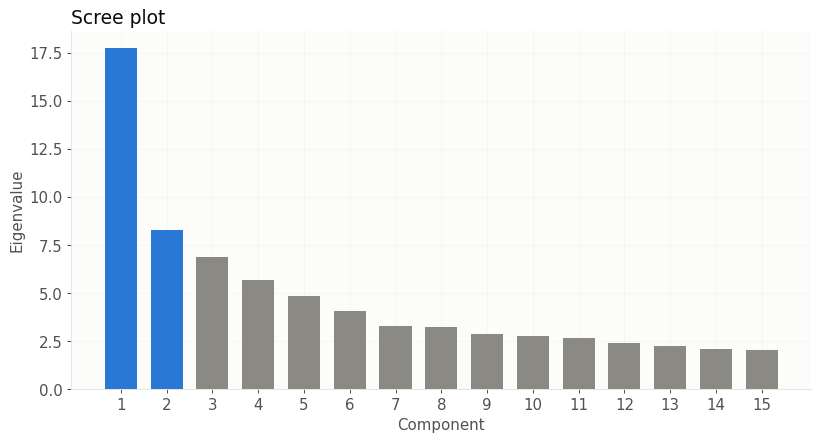

In [6]:
fig = res.plot("eigenvalues", backend="matplotlib", max_components=15)
show(fig, "03_eigenvalues")

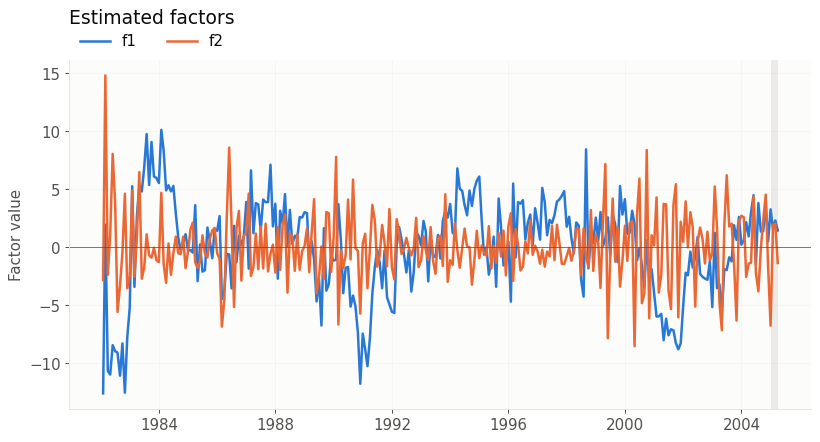

In [7]:
fig = res.plot("factors", backend="matplotlib")
show(fig, "03_factors")

The first factor is visibly the US business cycle: it plunges in the 1990–1991 and
2001 recessions (NBER dates) and is otherwise remarkably stable, a hallmark of the
Great Moderation.

## 3. In-sample fit and residual autocorrelation, 1985–2004

If the factors summarise the predictable part of GDP growth, the bridge-equation
residuals should be close to white noise. We compute their autocorrelation function
over 1985–2004 with a Ljung-Box test.

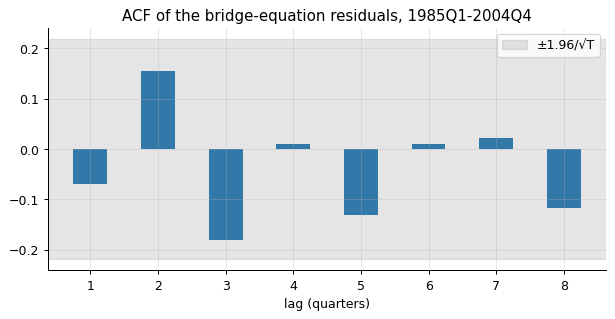

,Ljung-Box,p-value
4,5.2355,0.264
8,8.0459,0.429


In [8]:
resid = (res.observed - res.in_sample).dropna().loc["1985Q1":"2004Q4"]
rho = acf(resid.to_numpy(), nlags=8, fft=False)[1:]
band = 1.96 / np.sqrt(resid.size)
lb = acorr_ljungbox(resid.to_numpy(), lags=[4, 8], return_df=True)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(np.arange(1, 9), rho, width=0.5)
ax.axhspan(-band, band, color="grey", alpha=0.2, label="±1.96/√T")
ax.set_xlabel("lag (quarters)")
ax.set_title("ACF of the bridge-equation residuals, 1985Q1-2004Q4")
ax.legend()
show(fig, "03_residual_acf")
display(lb.rename(columns={"lb_stat": "Ljung-Box", "lb_pvalue": "p-value"}))

No autocorrelation is significant: the dynamics of GDP growth are captured by the
factors, and the residual is consistent with measurement noise and idiosyncratic
shocks — the same diagnostic conclusion as in the original study.

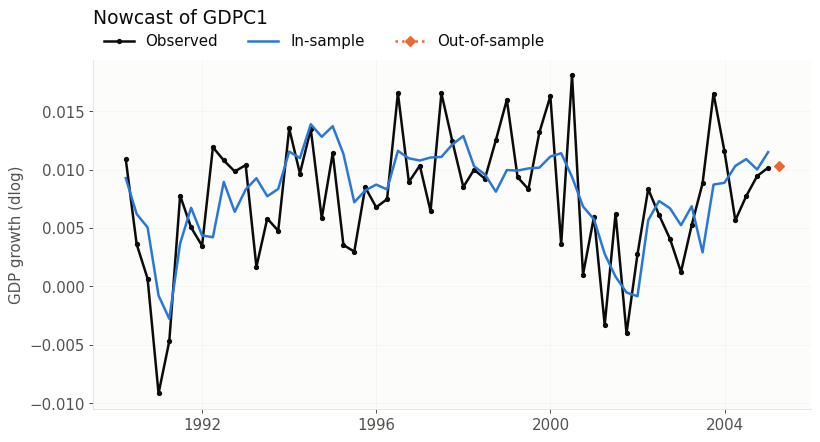

In [9]:
fig = res.plot("forecast", backend="matplotlib", start="1990Q1", ylabel="GDP growth (dlog)")
show(fig, "03_fit")

## 4. Pseudo real-time evaluation, 1995–2004

The key GRS exercise re-estimates the model every month on the information available
at that date (data truncated according to each series' publication delay) and nowcasts
the previous, current and next quarter. `PseudoRealTimeBacktest` does exactly that;
`months_to_end` indexes the horizon: the number of months between the vintage and the
end of the target quarter (5 = a forecast of next quarter made in the first month of
the current one; 0 = last month of the target quarter; −1 = one month after its end,
a *backcast* before the GDP release). Benchmarks: an AR(1) on GDP growth and a random
walk (the "naive" forecast of GRS).

Here the vintages are *pseudo* real time: revised data, truncated with the
stylised delays.

In [10]:
backtest = nb.PseudoRealTimeBacktest(
    model=nb.TwoStepDFM(n_factors=2, factor_lags=2, n_shocks=2),
    data=panel,
    target="GDPC1",
    start="1995-01-01",
    end="2004-12-01",
    step="M",
    benchmarks=[nb.benchmarks.AR(p=1), nb.benchmarks.RandomWalk()],
    n_jobs=4,
)
out = backtest.run()
print(out.summary())

Pseudo real-time backtest
Target: GDPC1    Models: TwoStepDFM, AR, RandomWalk
Vintages: 120 (1995-01-01 to 2004-12-01)    Target periods: 42

Accuracy (common sample, all horizons)
metric      rmsfe    mae    bias        n  rel_rmsfe
model                                               
TwoStepDFM 0.0049 0.0039 -0.0003 277.0000     0.9459
AR         0.0052 0.0039 -0.0004 277.0000     1.0000
RandomWalk 0.0064 0.0052  0.0001 277.0000     1.2409

RMSFE by months_to_end
               TwoStepDFM     AR  RandomWalk
months_to_end                               
-1                 0.0044 0.0053      0.0066
 0                 0.0044 0.0053      0.0065
 1                 0.0049 0.0053      0.0065
 2                 0.0050 0.0050      0.0060
 3                 0.0053 0.0050      0.0060
 4                 0.0051 0.0050      0.0060
 5                 0.0050 0.0052      0.0071


In [11]:
rmsfe = out.rmsfe_by_horizon()
relative = out.relative_to("RandomWalk")
display(
    pd.concat(
        {"RMSFE (pp of QoQ growth)": 100 * rmsfe, "relative to random walk": relative}, axis=1
    )
)

RMSFE (pp of QoQ growth)                    relative to random walk                   
                            TwoStepDFM      AR RandomWalk              TwoStepDFM      AR RandomWalk
months_to_end                                                                                       
-1                              0.4405  0.5333     0.6582                  0.6693  0.8102        1.0
 0                              0.4436  0.5294     0.6524                  0.6799  0.8114        1.0
 1                              0.4910  0.5294     0.6524                  0.7527  0.8114        1.0
 2                              0.4970  0.4981     0.5981                  0.8310  0.8329        1.0
 3                              0.5267  0.4998     0.6046                  0.8711  0.8267        1.0
 4                              0.5139  0.4998     0.6046                  0.8500  0.8267        1.0
 5                              0.4995  0.5204     0.7052                  0.7082  0.7380        1.0

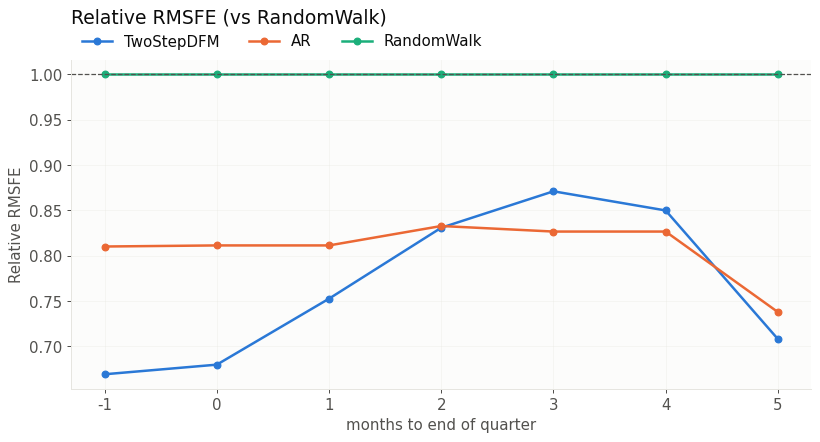

In [12]:
fig = nb.visualization.plot_rmsfe_by_horizon(
    rmsfe, relative_to="RandomWalk", backend="matplotlib", xlabel="months to end of quarter"
)
show(fig, "03_rmsfe")

In [13]:
dm = out.diebold_mariano(reference="RandomWalk").loc["TwoStepDFM"]
display(dm[["statistic", "pvalue", "n_obs"]])

,statistic,pvalue,n_obs
horizon,,,
-1,-2.9159,0.0059,40.0
0,-2.7693,0.0086,40.0
1,-2.0622,0.0459,40.0
2,-1.3887,0.1728,40.0
3,-1.1120,0.2731,39.0
4,-1.3387,0.1886,39.0
5,-2.2555,0.0299,39.0


In [14]:
vs_ar = rmsfe["TwoStepDFM"] / rmsfe["AR"]
display(vs_ar.rename("RMSFE DFM / RMSFE AR(1)").to_frame())
md(
    f"Relative to the AR(1), the DFM's RMSFE falls from **{vs_ar.loc[5]:.2f}** five "
    f"months before the end of the quarter (no data on it yet) and "
    f"**{vs_ar.loc[3]:.2f}** at its start to **{vs_ar.loc[0]:.2f}** in its last month "
    f"and **{vs_ar.loc[-1]:.2f}** for the backcast. Against the random walk the "
    f"Diebold-Mariano test (Harvey-Leybourne-Newbold correction) rejects equal accuracy "
    f"at the 5 % level for the backcast and nowcast horizons."
)

,RMSFE DFM / RMSFE AR(1)
months_to_end,
-1,0.8261
0,0.8379
1,0.9276
2,0.9977
3,1.0537
4,1.0282
5,0.9597


Relative to the AR(1), the DFM's RMSFE falls from **0.96** five months before the end of the quarter (no data on it yet) and **1.05** at its start to **0.84** in its last month and **0.83** for the backcast. Against the random walk the Diebold-Mariano test (Harvey-Leybourne-Newbold correction) rejects equal accuracy at the 5 % level for the backcast and nowcast horizons.

## 5. What we reproduce, and what we do not

* **Reproduced (qualitatively):** the precision of the DFM nowcast improves as the
  quarter's monthly data are released — the GRS *information flow* result — and the
  model significantly beats the naive benchmark when the current quarter's data are
  in. Far from the quarter, when no data on it exist, the factor model has no edge over
  a simple AR(1), exactly as GRS documented.
* **Not reproduced:** the exact RMSFE values and the comparison with the SPF. Revised
  data overstate real-time accuracy (the GDP figures we evaluate against are today's,
  not the first releases), the panel is smaller, and the delays are stylised. The
  Brazilian notebooks (06–08) use **real** GDP vintages from IBGE to avoid the first
  issue.

### References

* Doz, C., Giannone, D. & Reichlin, L. (2011). A two-step estimator for large
  approximate dynamic factor models based on Kalman filtering. *Journal of
  Econometrics*, 164(1), 188–205.
* Giannone, D., Reichlin, L. & Small, D. (2008). Nowcasting: the real-time
  informational content of macroeconomic data. *Journal of Monetary Economics*, 55(4),
  665–676.
* Diebold, F. X. & Mariano, R. S. (1995). Comparing predictive accuracy. *JBES*,
  13(3), 253–263; Harvey, D., Leybourne, S. & Newbold, P. (1997). Testing the equality
  of prediction mean squared errors. *IJF*, 13(2), 281–291.
* McCracken, M. W. & Ng, S. (2016). FRED-MD: a monthly database for macroeconomic
  research. *JBES*, 34(4), 574–589.
* de Valk, S., de Mattos, D. & Ferreira, P. (2019). Nowcasting: an R package for
  predicting economic variables using dynamic factor models. *The R Journal*, 11(1).